Цель: изучить применение методов оптимизации для решения задачи классификации

Описание задания:
В домашнем задании необходимо применить полученные знания в теории оптимизации и машинном обучении для реализации логистической регрессии.

- Загрузите данные. Используйте датасет с ирисами. Его можно загрузить непосредственно из библиотеки Sklearn. В данных оставьте только 2 класса: Iris Versicolor, Iris Virginica.
- Самостоятельно реализуйте логистическую регрессию, без использования метода LogisticRegression из библиотеки. Можете использовать библиотеки pandas, numpy, math для реализации. Оформите в виде функции. *Оформите в виде класса с методами.
- Реализуйте метод градиентного спуска. Обучите логистическую регрессию этим методом. Выберете и посчитайте метрику качества. Метрика должна быть одинакова для всех пунктов домашнего задания. Для упрощения сравнения выберете только одну метрику.
- Повторите п. 3 для метода скользящего среднего (Root Mean Square Propagation, RMSProp).
- Повторите п. 3 для ускоренного по Нестерову метода адаптивной оценки моментов (Nesterov–accelerated Adaptive Moment Estimation, Nadam).
- Сравните значение метрик для реализованных методов оптимизации. Можно оформить в виде таблицы вида |метод|метрика|время работы| (время работы опционально). Напишите вывод.

In [ ]:
import numpy as np
import pandas as pd
import sympy as sym
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

In [ ]:
data = load_iris()

In [ ]:
irises = pd.DataFrame(data=data.data, columns=data.feature_names)
irises.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [ ]:
irises['target'] = pd.Series(data=data.target)
irises.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


In [ ]:
iris = irises.loc[irises['target'] != 0]

In [ ]:
y = iris.target.map({1:0, 2:1})

In [ ]:
y.sample(5)

,target
52,0
125,1
80,0
132,1
95,0


In [ ]:
y.info()

<class 'pandas.core.series.Series'>
Index: 100 entries, 50 to 149
Series name: target
Non-Null Count  Dtype
--------------  -----
100 non-null    int64
dtypes: int64(1)
memory usage: 1.6 KB


In [ ]:
y.unique()

array([0, 1])

In [ ]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 50 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  100 non-null    float64
 1   sepal width (cm)   100 non-null    float64
 2   petal length (cm)  100 non-null    float64
 3   petal width (cm)   100 non-null    float64
 4   target             100 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 4.7 KB


In [ ]:
#del iris['target']

In [ ]:
iris = iris[['sepal length (cm)',	'sepal width (cm)',	'petal length (cm)',	'petal width (cm)']]

In [ ]:
iris.columns = ['sepal_length',	'sepal_width', 'petal_length', 'petal_width']

In [ ]:
iris['bias'] = 1.

In [ ]:
iris.sample(4)

,sepal_length,sepal_width,petal_length,petal_width,bias
113,5.7,2.5,5.0,2.0,1.0
132,6.4,2.8,5.6,2.2,1.0
149,5.9,3.0,5.1,1.8,1.0
56,6.3,3.3,4.7,1.6,1.0


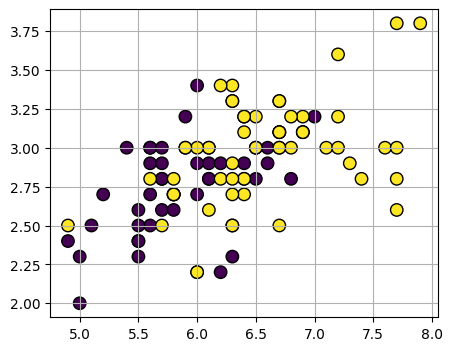

In [ ]:
plt.figure(figsize=(5, 4))
plt.scatter(iris['sepal_length'], iris['sepal_width'], c=y, edgecolor='k', s=80)
plt.grid()
plt.show()

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(iris, y, test_size=.25, random_state=0)

In [ ]:
x_train.shape, x_test.shape

((75, 5), (25, 5))

In [ ]:
# вариант как сгенерировать начальные веса для всех признаков
# ws = np.random.normal(size=(iris.shape[1],))
# здесь можно указать среднее (loc) и разброс (scale), если они отличны от 0 и 1 соответственно
# ws

Вариант последний

In [ ]:
def sigmoid(data):
  return 1 / (1 + np.exp(-data))

def logloss(y_train, proba):
  return -(np.sum(np.log(proba[y_train==1] + 1e-30)) + np.sum(np.log(1 - proba[y_train==0] + 1e-30))) / len(y_train)

def grad(x_train, y_train, weights):
  proba = sigmoid(x_train @ weights)
  return x_train.T @ (proba - y_train)

def logreg(lr = 0.0001, epoch = 500):
  weights = np.random.randn(len(iris.columns))
  results_loss = []
  all_weights = []
  acc = []
  for _ in range(epoch):
    proba = sigmoid(x_train @ weights)
    loss = logloss(y_train, proba)
    results_loss.append(loss)
    new_weights = weights - lr * grad(x_train, y_train, weights)
    all_weights.append(new_weights)
    pred = np.where(proba >= 0.5, 1, 0)
    accuracy = (pred==y_train).sum() / len(y_train)
    acc.append(accuracy)
    weights = new_weights
    print(f"Потеря: {loss}, точность: {accuracy}", '\n')


  return results_loss, all_weights, acc

In [ ]:
results_loss, all_weights, acc = logreg()

Потеря: 0.9672256860905768, точность: 0.44 

Потеря: 0.9574369062890477, точность: 0.44 

Потеря: 0.9496837425107413, точность: 0.4 

Потеря: 0.9435504392777265, точность: 0.4 

Потеря: 0.9386954786174946, точность: 0.4 

Потеря: 0.934842522790563, точность: 0.38666666666666666 

Потеря: 0.9317706507625365, точность: 0.38666666666666666 

Потеря: 0.9293049355098985, точность: 0.37333333333333335 

Потеря: 0.9273079290030588, точность: 0.37333333333333335 

Потеря: 0.92567229431895, точность: 0.37333333333333335 

Потеря: 0.9243146213167881, точность: 0.37333333333333335 

Потеря: 0.9231703492620447, точность: 0.37333333333333335 

Потеря: 0.9221896663816669, точность: 0.37333333333333335 

Потеря: 0.9213342395022943, точность: 0.37333333333333335 

Потеря: 0.9205746306610845, точность: 0.37333333333333335 

Потеря: 0.9198882715496512, точность: 0.37333333333333335 

Потеря: 0.9192578845948295, точность: 0.36 

Потеря: 0.9186702578619217, точность: 0.36 

Потеря: 0.9181152979765691, точ

In [ ]:
results_loss[-1], all_weights[-1], acc[-1]

(0.7334018464928836,
 sepal_length   -0.934361
 sepal_width     1.313108
 petal_length    0.060873
 petal_width     0.440802
 bias            1.252082
 dtype: float64,
 0.49333333333333335)

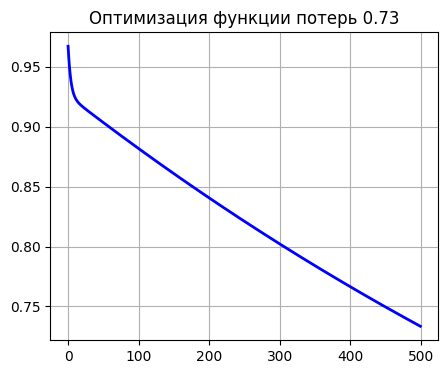

In [ ]:
plt.figure(figsize=(5, 4))
plt.plot(results_loss, 'b', linewidth=2)
plt.title(f'Оптимизация функции потерь {round(results_loss[-1],2)}')
plt.grid()
plt.show()

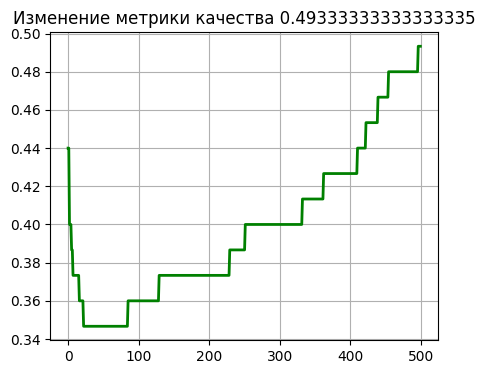

In [ ]:
plt.figure(figsize=(5, 4))
plt.plot(acc, 'g', linewidth=2)
plt.title(f'Изменение метрики качества {acc[-1]}')
plt.grid()
plt.show()

Вариант предпоследний

In [ ]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

In [ ]:
def log_loss(y, y_pred):
  class_1 = np.sum(np.log(y_pred[y==1] + 1e-30))
  class_0 = np.sum(np.log(1 - y_pred[y==0] + 1e-30))
  return -(class_1 + class_0) / len(y)

In [ ]:
def gr_log_loss(x, y, w):
  y_pred = sigmoid(x @ w)
  return x.T @ (y_pred - y)

In [ ]:
def grad_rmsprop(x, y, w, beta=0.9, lr = 0.005, eps=1e-20):
  x_0 = x.iloc[:, 0]
  x_1 = x.iloc[:, 1]
  x_2 = x.iloc[:, 2]
  x_3 = x.iloc[:, 3]
  x_4 = x.iloc[:, 4]

  exp_avg_0, exp_avg_1, exp_avg_2, exp_avg_3, exp_avg_4 = 0, 0, 0, 0, 0

  exp_avg_0 = (beta * exp_avg_0) + (1 - beta) * (((x_0 * np.sum(sigmoid(x_0 * w[0]) - y)) / x.shape[0])**2)
  exp_avg_1 = (beta * exp_avg_1) + (1 - beta) * (((x_1 * np.sum(sigmoid(x_1 * w[1]) - y)) / x.shape[0])**2)
  exp_avg_2 = (beta * exp_avg_2) + (1 - beta) * (((x_2 * np.sum(sigmoid(x_2 * w[2]) - y)) / x.shape[0])**2)
  exp_avg_3 = (beta * exp_avg_3) + (1 - beta) * (((x_3 * np.sum(sigmoid(x_3 * w[3]) - y)) / x.shape[0])**2)
  exp_avg_4 = (beta * exp_avg_4) + (1 - beta) * ((np.sum(sigmoid(x_4 * w[4]) - y) / x.shape[0])**2)


  w_0 = w[0] - (lr / (np.sqrt(exp_avg_0) + eps)) * ((x_0 * np.sum(sigmoid(x_0 * w[0]) - y)) / x.shape[0])
  w_1 = w[1] - (lr / (np.sqrt(exp_avg_1) + eps)) * ((x_1 * np.sum(sigmoid(x_1 * w[1]) - y)) / x.shape[0])
  w_2 = w[2] - (lr / (np.sqrt(exp_avg_2) + eps)) * ((x_2 * np.sum(sigmoid(x_2 * w[2]) - y)) / x.shape[0])
  w_3 = w[3] - (lr / (np.sqrt(exp_avg_3) + eps)) * ((x_3 * np.sum(sigmoid(x_3 * w[3]) - y)) / x.shape[0])
  w_4 = w[4] - (lr / (np.sqrt(exp_avg_4) + eps)) * ((np.sum(sigmoid(x_4 * w[4]) - y)) / x.shape[0])

  w_0 = np.sum(w_0) / len(w_0)
  w_1 = np.sum(w_1) / len(w_1)
  w_2 = np.sum(w_2) / len(w_2)
  w_3 = np.sum(w_3) / len(w_3)

  return np.array([w_0, w_1, w_2, w_3, w_4])

In [ ]:
wes = np.random.randn(len(iris))
res = grad_rmsprop(iris, y, wes)

In [ ]:
res

array([1.74824096, 0.38434582, 0.9629266 , 2.22508181, 1.8517466 ])

In [ ]:
def grad_nadam():
  return

In [ ]:
np.random.seed(0)

def alltogether(epoch = 500, eps = 0.0001, lr = 0.005, gradient=gr_log_loss):
  new = np.random.randn(iris.shape[1])
  weights = []
  metric = []
  lost = []

  for i in range(epoch):
    current = new
    if gradient == True:
      new = current - lr * gradient(iris, y, current)
    else:
      new = current - lr * gradient(iris, y, current)

    weights.append(new)

    if np.linalg.norm(current - new) <= eps:
      break

    if i % 50 == 0:
      print(f"Итерация: {i}")

      pred = sigmoid(iris @ new)
      y_class = np.where(pred >= 0.5, 1, 0)
      accuracy = (y_class == y).sum() / len(y)
      metric.append(accuracy)
      loss = log_loss(y, pred)
      lost.append(loss)

      print(f"Logloss = {loss}")
      print(f"Accuracy = {accuracy}")
      print('-.-.-.-.-.-.-.-.-.-.-.-')
  return weights, metric, lost

In [ ]:
weights, metric, lost = alltogether()  #(gradient=grad_rmsprop)

Итерация: 0
50     0.992683
51     0.992969
52     0.993850
53     0.990269
54     0.993859
         ...   
145    0.998586
146    0.997121
147    0.997351
148    0.998141
149    0.995458
Length: 100, dtype: float64
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1] 50     0
51     0
52     0
53     0
54     0
      ..
145    1
146    1
147    1
148    1
149    1
Name: target, Length: 100, dtype: int64
Logloss = 2.323893232503322
Accuracy = 0.5
-.-.-.-.-.-.-.-.-.-.-.-
Итерация: 50
50     0.999786
51     0.999876
52     0.999946
53     0.999881
54     0.999947
         ...   
145    1.000000
146    0.999999
147    0.999999
148    1.000000
149    0.999998
Length: 100, dtype: float64
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 

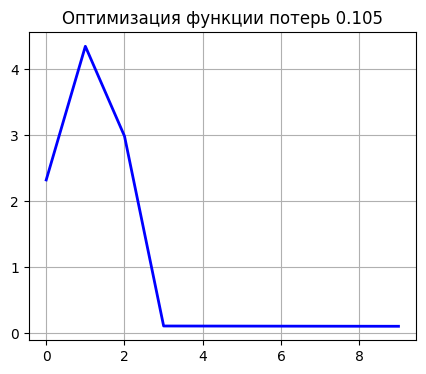

In [ ]:
plt.figure(figsize=(5, 4))
plt.plot(lost, 'b', linewidth=2)
plt.title(f'Оптимизация функции потерь {round(lost[-1],3)}')
plt.grid()
plt.show()

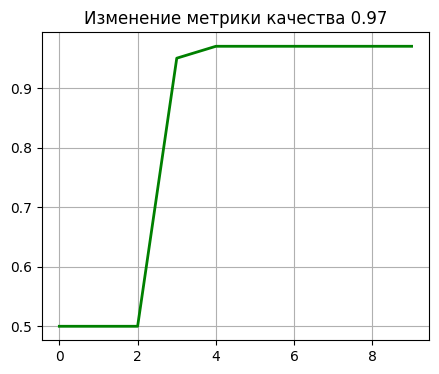

In [ ]:
plt.figure(figsize=(5, 4))
plt.plot(metric, 'g', linewidth=2)
plt.title(f'Изменение метрики качества {metric[-1]}')
plt.grid()
plt.show()

In [ ]:
weights[-1]

array([-0.08356382,  0.08809841, -0.04976653, -0.04919125, -0.10352513])

Вариант первый

In [ ]:
iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [ ]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [ ]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [ ]:
x = iris.data
y = iris.target

In [ ]:
df = pd.DataFrame(x, columns=iris.feature_names)
df['target'] = y

In [ ]:
df = df.loc[df['target'] > 0]
df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
138,6.0,3.0,4.8,1.8,2
68,6.2,2.2,4.5,1.5,1
111,6.4,2.7,5.3,1.9,2
75,6.6,3.0,4.4,1.4,1
71,6.1,2.8,4.0,1.3,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 50 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  100 non-null    float64
 1   sepal width (cm)   100 non-null    float64
 2   petal length (cm)  100 non-null    float64
 3   petal width (cm)   100 non-null    float64
 4   target             100 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 4.7 KB


In [ ]:
# заменяю метку класса 2 на 0 и теперь 0 - virginica, 1 - versicolor

df.loc[df['target'] == 2, 'target'] = 0
df['target'].value_counts()

,count
target,
1,50
0,50


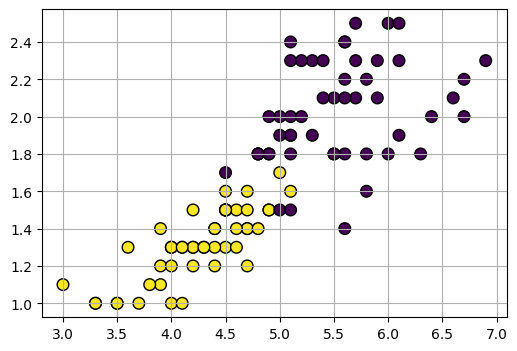

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(df['petal length (cm)'], df['petal width (cm)'], c=df.target, s=70, edgecolor='k')
plt.grid()
plt.show()

In [ ]:
#def sigmoid(z):
  # return 1 / (1 + np.exp(-w[0] + x[1]*w[1] + x[2]*w[2] + x[3]*w[3] + x[4]*w[4]))

In [ ]:
#def logloss(*params):
   #err = -np.sum(y*np.log(sigmoid(z)) + (1 - y)* np.log(1 - sigmoid(z)))
   #return err

In [ ]:
df.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
50,7.0,3.2,4.7,1.4,1
51,6.4,3.2,4.5,1.5,1
52,6.9,3.1,4.9,1.5,1


In [ ]:
x1 = x[:, 0]
x2 = x[:, 1]
x3 = x[:, 2]
x4 = x[:, 3]

lrate = 0.005
epochs = 100
#line = []
error = []
w = np.random.normal(size=(5,))

for _ in range(epochs):
    linear = w[0] + w[1]*x1 + w[2]*x2 + w[3]*x3 + w[4]*x4
    #line.append(linear)
    sigm = 1 / (1 + np.exp(-linear))
    err = np.sum(y * np.log(sigm + 1e-20)) + np.sum((1 - y) * np.log(1 - sigm + 1e-20))
    err = -err / len(y)
    error.append(err)

    w[0] -= lrate * np.sum(sigm - y) / len(linear)
    w[1] -= lrate * np.sum((sigm - y) * x1) / len(linear)
    w[2] -= lrate * np.sum((sigm - y) * x2) / len(linear)
    w[3] -= lrate * np.sum((sigm - y) * x3) / len(linear)
    w[4] -= lrate * np.sum((sigm - y) * x4) / len(linear)

    print("w0:", w[0], "w1:", w[1], "w2:", w[2], "w3:", w[3], "w4:", w[4])
    print(err)

w0: 0.8674659945174235 w1: 0.0551872851053071 w2: -0.27459881049245016 w3: 1.3789928518377215 w4: -0.2930845132630269
-1.7232483489600987
w0: 0.8676504064188004 w1: 0.05875234663567763 w2: -0.274724451116018 w3: 1.386091081690023 w4: -0.2900655990515963
-1.7377455668469513
w0: 0.8678300191622375 w1: 0.062292990347097905 w2: -0.27486645341577726 w3: 1.3931814059698135 w4: -0.2870482754594966
-1.7521824543592273
w0: 0.8680049813851791 w1: 0.06580998343814591 w2: -0.2750243154037052 w3: 1.400264098864112 w4: -0.28403248133066733
-1.7665613912930034
w0: 0.8681754360034685 w1: 0.06930406303409037 w2: -0.2751975541155918 w3: 1.4073394224187554 w4: -0.2810181585122458
-1.780884637986458
w0: 0.868341520485051 w1: 0.0727759376562134 w2: -0.27538570471945173 w3: 1.4144076272122605 w4: -0.27800525167257323
-1.7951543426768195
w0: 0.8685033671079024 w1: 0.07622628860440037 w2: -0.2755883196740943 w3: 1.421468952984642 w4: -0.2749937081322571
-1.8093725483229441
w0: 0.8686611032032429 w1: 0.0796557

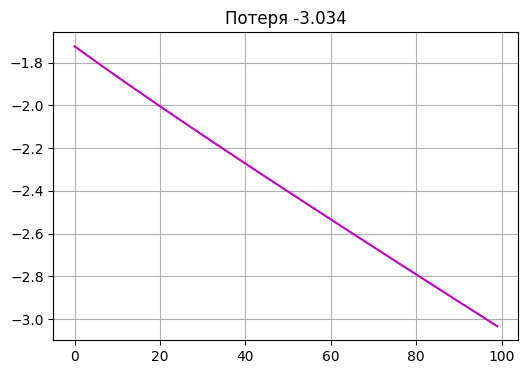

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(error, 'm')
plt.title(f'Потеря {round(error[-1],3)}')
plt.grid()
plt.show()

“Алгоритм оптимизации” иногда увеличивает, иногда уменьшает значения весов. Значения весов могут меняться как угодно в процессе оптимизации, так как поверхность лосс-функции, которую мы оптимизируем, не с одним локальным минимумом.

In [ ]:
x1 = x[:, 0]
x2 = x[:, 1]
x3 = x[:, 2]
x4 = x[:, 3]

lrate = 0.005
epochs = 100
w = np.random.normal(size=(5,))

alpha = 0.7 # коэффициент забывания
exp_avg_0, exp_avg_1, exp_avg_2, exp_avg_3, exp_avg_4 = 0, 0, 0, 0, 0
eps = 1e-8

rmsp_error = []
rmsp_line = []

for _ in range(epochs):

    linear = w[0] + w[1]*x1 + w[2]*x2 + w[3]*x3 + w[4]*x4
    rmsp_line.append(linear)

    sigm = 1 / (1 + np.exp(-linear))

    err = -np.mean(y * np.log(sigm + 1e-20) + (1 - y)* np.log(1 - sigm + 1e-20))
    err = np.sum(err)
    rmsp_error.append(err)

    exp_avg_0 = (alpha * exp_avg_0) + ((1-alpha) * (np.sum(sigm - y) / len(linear))**2)
    exp_avg_1 = (alpha * exp_avg_1) + ((1-alpha) * (np.sum(x1 * (sigm - y)) / len(linear))**2)
    exp_avg_2 = (alpha * exp_avg_2) + ((1-alpha) * (np.sum(x2 * (sigm - y)) / len(linear))**2)
    exp_avg_3 = (alpha * exp_avg_3) + ((1-alpha) * (np.sum(x3 * (sigm - y)) / len(linear))**2)
    exp_avg_4 = (alpha * exp_avg_4) + ((1-alpha) * (np.sum(x4 * (sigm - y)) / len(linear))**2)

    w[0] -= (lrate / np.sqrt(exp_avg_0 + eps)) * (np.sum(sigm - y) / len(linear))
    w[1] -= (lrate / np.sqrt(exp_avg_1 + eps)) * (np.sum(x1 * (sigm - y)) / len(linear))
    w[2] -= (lrate / np.sqrt(exp_avg_2 + eps)) * (np.sum(x2 * (sigm - y)) / len(linear))
    w[3] -= (lrate / np.sqrt(exp_avg_3 + eps)) * (np.sum(x3 * (sigm - y)) / len(linear))
    w[4] -= (lrate / np.sqrt(exp_avg_4 + eps)) * (np.sum(x4 * (sigm - y)) / len(linear))


    print("w0:", w[0], "w1:", w[1], "w2:", w[2], "w3:", w[3], "w4:", w[4])
    print(rmsp_error)

w0: -0.20888817454349975 w1: 0.46878582680945746 w2: -0.289162589503319 w3: -2.4157176021197806 w4: 0.261864080147311
[10.152366953456747]
w0: -0.2018949727080893 w1: 0.4757808000080681 w2: -0.2821709265034831 w3: -2.4087184461185016 w4: 0.2688643717390459
[10.152366953456747, 9.998501140001107]
w0: -0.1957381536711919 w1: 0.4819401679041809 w2: -0.2760163296392999 w3: -2.4025530629359433 w4: 0.2750313866564868
[10.152366953456747, 9.998501140001107, 9.880776370491471]
w0: -0.190016633234677 w1: 0.4876647707241124 w2: -0.2702975051926148 w3: -2.3968211907695136 w4: 0.2807652291236836
[10.152366953456747, 9.998501140001107, 9.880776370491471, 9.777254387800863]
w0: -0.18455103572225776 w1: 0.4931338847314558 w2: -0.2648349927685067 w3: -2.3913437902429915 w4: 0.28624487380419256
[10.152366953456747, 9.998501140001107, 9.880776370491471, 9.777254387800863, 9.681165290543595]
w0: -0.1792461194668633 w1: 0.4984426994434338 w2: -0.2595335068183828 w3: -2.386025797188198 w4: 0.29156535047715

In [ ]:
exp_avg_0, exp_avg_1, exp_avg_2, exp_avg_3, exp_avg_4

(0.29262565663475226,
 15.360035725131002,
 2.014294168480345,
 16.153798003866655,
 2.2513789492838314)

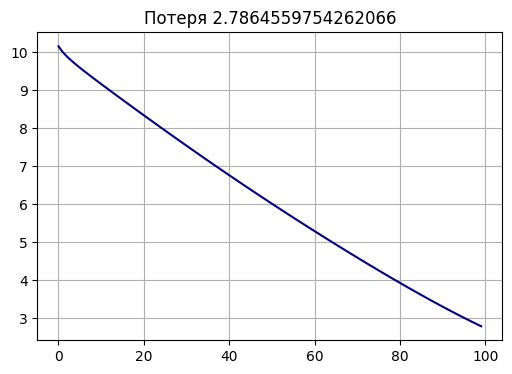

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(rmsp_error, color='navy')
plt.title(f"Потеря {rmsp_error[-1]}")
plt.grid()
plt.show()

In [ ]:
x1 = x[:, 0]
x2 = x[:, 1]
x3 = x[:, 2]
x4 = x[:, 3]

lrate = 0.005
epochs = 100
w = np.random.normal(size=(5,))

alpha = 0.8
exp_avg_0, exp_avg_1, exp_avg_2, exp_avg_3, exp_avg_4 = 0, 0, 0, 0, 0

nest_error = []
nest_line = []

for _ in range(epochs):
    exp_avg_0 = (alpha * exp_avg_0) + ((1-alpha) * (np.sum(sigm - y) / len(linear))**2)
    exp_avg_1 = (alpha * exp_avg_1) + ((1-alpha) * (np.sum(x1 * (sigm - y)) / len(linear))**2)
    exp_avg_2 = (alpha * exp_avg_2) + ((1-alpha) * (np.sum(x2 * (sigm - y)) / len(linear))**2)
    exp_avg_3 = (alpha * exp_avg_3) + ((1-alpha) * (np.sum(x3 * (sigm - y)) / len(linear))**2)
    exp_avg_4 = (alpha * exp_avg_4) + ((1-alpha) * (np.sum(x4 * (sigm - y)) / len(linear))**2)

    nester_0 = w[0] - (alpha * exp_avg_0)
    nester_1 = w[1] - (alpha * exp_avg_1)
    nester_2 = w[2] - (alpha * exp_avg_2)
    nester_3 = w[3] - (alpha * exp_avg_3)
    nester_4 = w[4] - (alpha * exp_avg_4)

    linear = nester_0 + nester_1 * x1 + nester_2 * x2 + nester_3 * x3 + nester_4 * x4
    nest_line.append(linear)

    sigm = 1 / (1 + np.exp(-linear))

    err = np.sum(((-y) * np.log(sigm)) - ((1 - y) * np.log(1 - sigm))) / len(linear)
    nest_error.append(err)


    """w[0] -= (alpha * exp_avg_0) + (lrate * (1-alpha)) * np.sum(sigm - y) / len(linear)
    w[1] -= (alpha * exp_avg_1) + (lrate * (1-alpha)) * np.sum(x1 * (sigm - y)) / len(linear)
    w[2] -= (alpha * exp_avg_2) + (lrate * (1-alpha)) * np.sum(x2 * (sigm - y)) / len(linear)
    w[3] -= (alpha * exp_avg_3) + (lrate * (1-alpha)) * np.sum(x3 * (sigm - y)) / len(linear)
    w[4] -= (alpha * exp_avg_4) + (lrate * (1-alpha)) * np.sum(x4 * (sigm - y)) / len(linear)"""

    w[0] -= (lrate / np.sqrt(exp_avg_0 + eps)) * #(np.sum(sigm - y) / len(linear))
    w[1] -= (lrate / np.sqrt(exp_avg_1 + eps)) * (np.sum(x1 * (sigm - y)) / len(linear))
    w[2] -= (lrate / np.sqrt(exp_avg_2 + eps)) * (np.sum(x2 * (sigm - y)) / len(linear))
    w[3] -= (lrate / np.sqrt(exp_avg_3 + eps)) * (np.sum(x3 * (sigm - y)) / len(linear))
    w[4] -= (lrate / np.sqrt(exp_avg_4 + eps)) * (np.sum(x4 * (sigm - y)) / len(linear))

    print("w0:", w[0], "w1:", w[1], "w2:", w[2], "w3:", w[3], "w4:", w[4])
    print(err)


w0: -0.2434293673889631 w1: 0.40159660849500894 w2: -1.3783091773768799 w3: -1.7999365087106765 w4: 1.8534138817302621
7.667937551100452
w0: -0.4015749322523062 w1: -6.100961648434431 w2: -2.7204155237601046 w3: -6.227871155824369 w4: 1.295978489840041
76.82551409783407
w0: -0.6878913841429808 w1: -17.795397125089092 w2: -5.1446931608666855 w3: -13.965683424626434 w4: 0.33620410521675304
200.00660308589076
w0: -1.0767445456555205 w1: -33.64333437752393 w2: -8.43470783055195 w3: -24.351397790779195 w4: -0.9454414735929886
366.40443294849024
w0: -1.547627074865552 w1: -52.814073050582905 w2: -12.417312126300162 w3: -36.855433834812516 w4: -2.4845840077518933
567.3756555107237
w0: -2.0841330982335773 w1: -74.6430528601412 w2: -16.953988122898732 w3: -51.05412722115028 w4: -4.229724106190128
inf
w0: -2.6731379169279976 w1: -98.59862557889893 w2: -21.933921480177588 w3: -66.6085464813316 w4: -6.139662256051827
nan
w0: -3.304141771883534 w1: -124.25547262501624 w2: -27.268460726000672 w3: -8

<ipython-input-113-22fb1b183854>:32: RuntimeWarning: overflow encountered in exp
  sigm = 1 / (1 + np.exp(-linear))
<ipython-input-113-22fb1b183854>:34: RuntimeWarning: divide by zero encountered in log
  err = np.sum(((-y) * np.log(sigm)) - ((1 - y) * np.log(1 - sigm))) / len(linear)
<ipython-input-113-22fb1b183854>:34: RuntimeWarning: invalid value encountered in multiply
  err = np.sum(((-y) * np.log(sigm)) - ((1 - y) * np.log(1 - sigm))) / len(linear)


 -33.793268844295255 w1: -1363.0554360168587 w2: -284.9612584134421 w3: -884.0127260321145 w4: -106.26845814219246
nan
w0: -34.59224651377734 w1: -1395.5164758198284 w2: -291.7140326726123 w3: -904.9894721256585 w4: -108.83751840040927
nan
w0: -35.39122864936301 w1: -1427.9776965333153 w2: -298.4668446399484 w3: -925.9663335516047 w4: -111.40659267809382
nan
w0: -36.19021435783154 w1: -1460.439061975216 w2: -305.21968677381733 w3: -946.9432872434729 w4: -113.97567817135257
nan
w0: -36.98920292460637 w1: -1492.9005431998476 w2: -311.9725530409125 w3: -967.9203147480786 w4: -116.54477263707068
nan
w0: -37.788193778026226 w1: -1525.362117050664 w2: -318.7254386145886 w3: -988.8974013028742 w4: -119.11387428075628
nan
w0: -38.58718646076211 w1: -1557.8237650024282 w2: -325.47833963352946 w3: -1009.8745350978218 w4: -121.68298166681588
nan
w0: -39.38618060695082 w1: -1590.2854722349507 w2: -332.2312530086822 w3: -1030.851706684891 w4: -124.25209364677467
nan
w0: -40.185175923901795 w1: -162

In [ ]:
nester_0, nester_1, nester_2, nester_3, nester_4

(-76.14115719252159,
 -3083.540334798092,
 -642.8702501161815,
 -1995.8130701209038,
 -242.43380916917098)

In [ ]:
exp_avg_0, exp_avg_1, exp_avg_2, exp_avg_3, exp_avg_4

(0.9999999997450305,
 40.58539376744961,
 8.444835997847246,
 26.228055104526796,
 3.213653776977409)

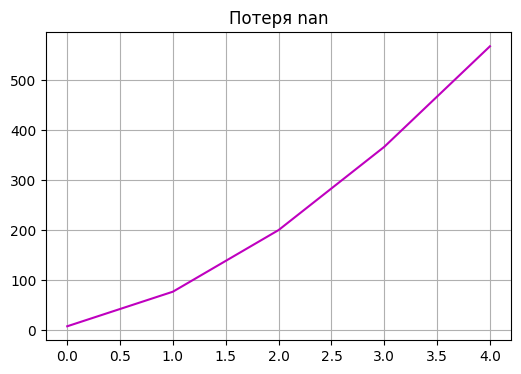

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(nest_error, color='m')
plt.title(f"Потеря {nest_error[-1]}")
plt.grid()
plt.show()

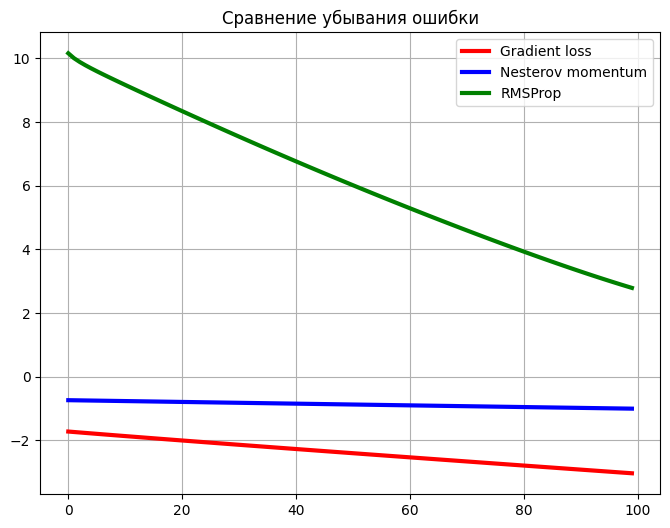

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(error, color='red', lw=3, label='Gradient loss')
plt.plot(nest_error, color='blue', lw=3, label='Nesterov momentum')
plt.plot(rmsp_error, color='green', lw=3, label='RMSProp')
plt.title('Сравнение убывания ошибки')
plt.grid()
plt.legend()
plt.show()